# Avaliação do Preditor de Preço - Joinville

Análise completa do modelo treinado para prever o valor de imóveis em Joinville.

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sys

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

In [2]:
CIDADE = "joinville"
MES_REF = "2026-09"
PASTA_DADOS = Path("../dados") / CIDADE

ARQUIVO_MODELO = PASTA_DADOS / f"{CIDADE}_modelo_geral_{MES_REF}.joblib"
ARQUIVO_OTIM = PASTA_DADOS / f"{CIDADE}_otimizados_melhores_incrementos_{MES_REF}.parquet"
ARQUIVO_TARGET = PASTA_DADOS / f"{CIDADE}_target_transform_{MES_REF}.json"
ARQUIVO_DADOS = PASTA_DADOS / f"{CIDADE}_imoveis_limpo_{MES_REF}.parquet"

print(f"Modelo:    {ARQUIVO_MODELO}")
print(f"Otimizacao: {ARQUIVO_OTIM}")
print(f"Target:    {ARQUIVO_TARGET}")
print(f"Dados:     {ARQUIVO_DADOS}")

Modelo:    ..\dados\joinville\joinville_modelo_geral_2026-09.joblib
Otimizacao: ..\dados\joinville\joinville_otimizados_melhores_incrementos_2026-09.parquet
Target:    ..\dados\joinville\joinville_target_transform_2026-09.json
Dados:     ..\dados\joinville\joinville_imoveis_limpo_2026-09.parquet


## 1. Carregar Melhor Config da Otimização

In [3]:
df_otim = pd.read_parquet(ARQUIVO_OTIM)
best_idx = df_otim["rmse_otimizado"].idxmin()
best = df_otim.loc[best_idx]

feat_map = json.loads(best.get("feature_transform_map", "{}"))
best_features = list(feat_map.keys())

print(f"Melhor modelo: {best['modelo']}")
print(f"RMSE otimizado: {best['rmse_otimizado']:,.0f}")
print(f"R2 original: {best['r2_original']:.3f}")
print(f"MAPE original: {best['mape_original']:.1f}%")
print(f"MDAPE original: {best['mdape_original']:.1f}%")
print(f"Target transform: {best.get('target_transform', 'none')}")
print(f"Features ({len(best_features)}): {best_features}")
print(f"Tratamento: {best['tratamento']}")
print(f"Scaler: {best['scaler']}")

Melhor modelo: GradientBoosting
RMSE otimizado: 2,014,300
R2 original: 0.185
MAPE original: 16.5%
MDAPE original: 11.4%
Target transform: log
Features (35): ['metro_quadrado_bairro_mean', 'vagas', 'metragem', 'predicao_idade', 'metro_quadrado_bairro_median', 'quartos', 'banheiros', 'componente_2', 'componente_1', 'comum_elevador', 'componente_3', 'score_parque', 'score_hospitais', 'dist_centro', 'priv_churrasqueira', 'score_farmacia', 'score_mercado', 'componente_0', 'score_escola_privada', 'lat', 'score_seguranca', 'priv_piscina', 'lng', 'score_escola_publica', 'comum_academia', 'priv_varanda', 'valor_bairro_mean', 'sem_rua', 'suites', 'score_educacao', 'comum_salao', 'comum_churrasqueira', 'comum_playground', 'tipo_imovel', 'bairro']
Tratamento: robust_median_ohe
Scaler: RobustScaler


## 2. Carregar Modelo

In [4]:
modelo = joblib.load(ARQUIVO_MODELO)
print(f"Modelo carregado: {ARQUIVO_MODELO.name}")
print(f"Tipo: {type(modelo).__name__}")

if Path(ARQUIVO_TARGET).exists():
    with open(ARQUIVO_TARGET) as f:
        meta_target = json.load(f)
    target_transform = meta_target.get("target_transformer", "none")
else:
    target_transform = "none"
print(f"Target transform: {target_transform}")

c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.9.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.9.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: T

Modelo carregado: joinville_modelo_geral_2026-09.joblib
Tipo: Pipeline
Target transform: log


c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.9.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.9.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning

## 3. Carregar e Preparar Dados

In [5]:
sys.path.append("../src")
from criando_indices_individuais import CriandoIndicesIndividuais
from funcoes_engenharia_features import engenharia_features_completa

df = pd.read_parquet(ARQUIVO_DADOS)
print(f"Parquet limpo: {len(df)} linhas, {len(df.columns)} colunas")

mask = (
    (df["metragem"] > 10)
    & (df["tipo_imovel"].isin(["casa", "apartamento"]))
    & (df["preco_por_m2"] >= 100)
)
df_modelo = df[mask].copy()
df_modelo = df_modelo.dropna(subset=["valor_imovel"])
print(f"Apos filtros basicos: {len(df_modelo)} linhas")

antes = len(df_modelo)
df_modelo = df_modelo[
    (df_modelo["valor_imovel"] > 0) &
    (df_modelo["valor_imovel"] <= 6_000_000)
]
print(f"Filtro outliers (<=6M): {antes} -> {len(df_modelo)} ({antes - len(df_modelo)} removidos)")

indices = None
try:
    indices = CriandoIndicesIndividuais(cidade="Joinville, Santa Catarina, Brasil", cache_dir=PASTA_DADOS)
    df_modelo = indices.calcular_indices(imoveis_df=df_modelo)
    print("Indices de localizacao calculados.")
except Exception as e:
    print(f"Erro ao calcular indices: {e}. Usando medias do bairro.")

df_modelo, _ = engenharia_features_completa(df_modelo, df_modelo.copy())

from sklearn.model_selection import train_test_split
train, test = train_test_split(df_modelo, test_size=0.25, random_state=42)

if any(c.startswith("componente_") for c in best_features):
    topicos_path = PASTA_DADOS / f"{CIDADE}_topicos_modelo.pkl"
    if topicos_path.exists():
        topicos_data = joblib.load(topicos_path)
        from utils_topicos import aplicar_topicos
        aplicar_topicos(train, topicos_data)
        aplicar_topicos(test, topicos_data)
        print("Topicos aplicados em train/test.")
    else:
        print("Modelo de topicos nao encontrado. Zerando colunas componente_*.")
        for c in best_features:
            if c.startswith("componente_"):
                train[c] = 0.0
                test[c] = 0.0

print(f"Treino: {len(train)} | Teste: {len(test)}")

Parquet limpo: 24235 linhas, 83 colunas
Apos filtros basicos: 22217 linhas
Filtro outliers (<=6M): 22217 -> 22107 (110 removidos)
  Carregando POIs do cache: ..\dados\joinville\pois_joinville_santa_catarina_brasil.parquet
Indices de localizacao calculados.
Topicos aplicados em train/test.
Treino: 16580 | Teste: 5527


## 4. Predizer e Calcular Métricas

In [6]:
X_test = test[best_features].copy()
y_test = test["valor_imovel"].values

y_pred_raw = modelo.predict(X_test)
if target_transform == "log":
    y_pred = np.expm1(y_pred_raw)
else:
    y_pred = y_pred_raw

erro = y_test - y_pred
erro_abs = np.abs(erro)
erro_pct = np.where(y_test != 0, 100 * erro_abs / y_test, np.nan)

test = test.copy()
test["valor_predito"] = y_pred
test["erro"] = erro
test["erro_abs"] = erro_abs
test["erro_percentual"] = erro_pct

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mdape = np.nanmedian(erro_pct)

print(f"Metricas no conjunto de teste ({len(test)} registros):")
print(f"  RMSE:   R$ {rmse:,.0f}")
print(f"  MAE:    R$ {mae:,.0f}")
print(f"  R2:     {r2:.3f}")
print(f"  MDAPE:  {mdape:.1f}%")

Metricas no conjunto de teste (5527 registros):
  RMSE:   R$ 180,631
  MAE:    R$ 104,264
  R2:     0.941
  MDAPE:  8.0%


## 5. Scatter Plot: Real vs Predito

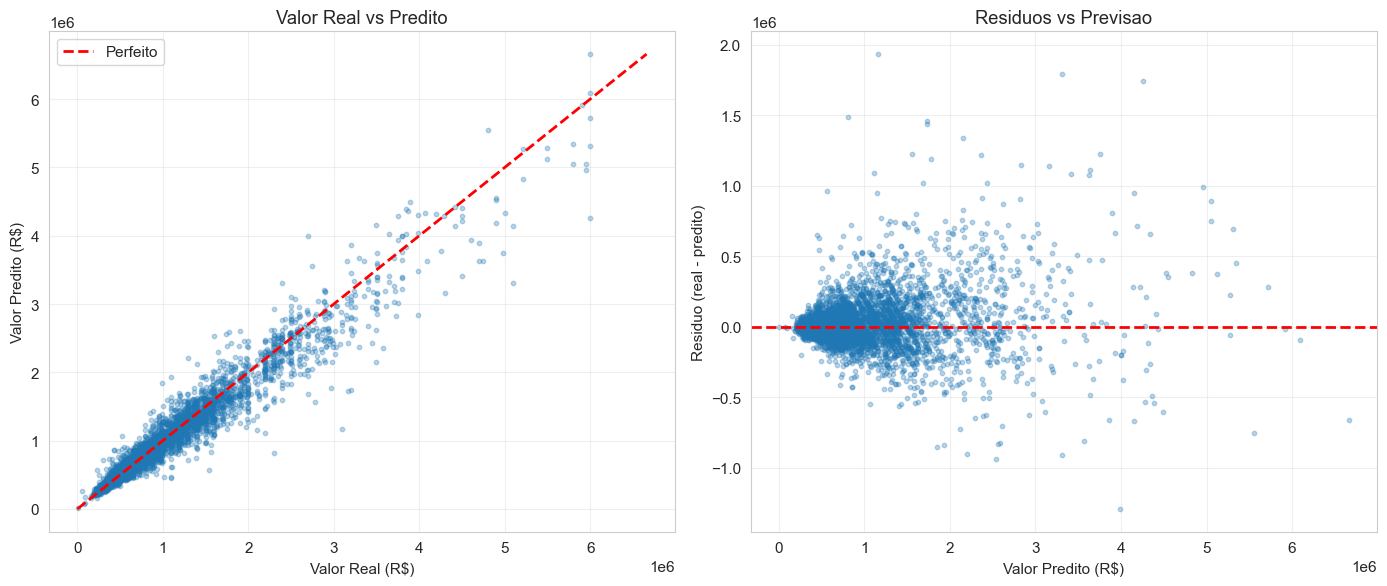

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(test["valor_imovel"], test["valor_predito"], alpha=0.3, s=10)
max_val = max(test["valor_imovel"].max(), test["valor_predito"].max())
axes[0].plot([0, max_val], [0, max_val], "r--", lw=2, label="Perfeito")
axes[0].set_xlabel("Valor Real (R$)")
axes[0].set_ylabel("Valor Predito (R$)")
axes[0].set_title("Valor Real vs Predito")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(test["valor_predito"], test["erro"], alpha=0.3, s=10)
axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
axes[1].set_xlabel("Valor Predito (R$)")
axes[1].set_ylabel("Residuo (real - predito)")
axes[1].set_title("Residuos vs Previsao")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Histograma de Erros

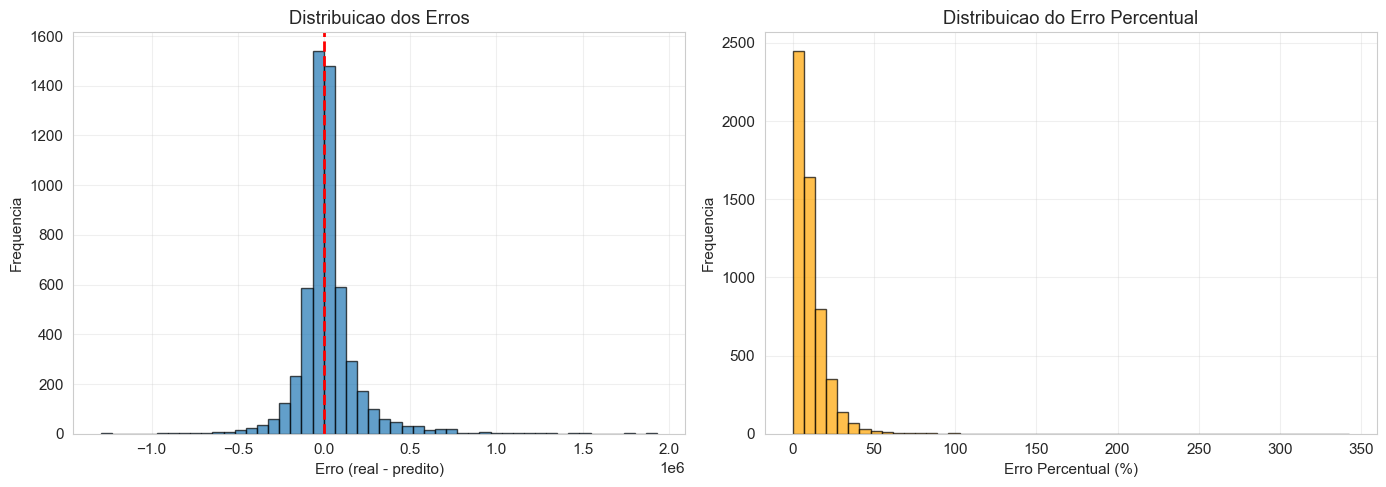

Erro medio: R$ 20,818
Erro absoluto medio: R$ 104,264
Mediana erro absoluto: R$ 55,232
95o percentil erro absoluto: R$ 375,338


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(test["erro"], bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(x=0, color="r", linestyle="--", lw=2)
axes[0].set_xlabel("Erro (real - predito)")
axes[0].set_ylabel("Frequencia")
axes[0].set_title("Distribuicao dos Erros")
axes[0].grid(True, alpha=0.3)

axes[1].hist(test["erro_percentual"].dropna(), bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_xlabel("Erro Percentual (%)")
axes[1].set_ylabel("Frequencia")
axes[1].set_title("Distribuicao do Erro Percentual")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Erro medio: R$ {test['erro'].mean():,.0f}")
print(f"Erro absoluto medio: R$ {test['erro_abs'].mean():,.0f}")
print(f"Mediana erro absoluto: R$ {test['erro_abs'].median():,.0f}")
print(f"95o percentil erro absoluto: R$ {test['erro_abs'].quantile(0.95):,.0f}")

## 7. Metricas por Faixa de Preco

Metricas por faixa de preco:
                  n      rmse       mae   r2  mdape
faixa_preco                                        
0-200k         18.0   57354.0   34796.0  0.0   13.0
200k-400k    1048.0   43598.0   28279.0  0.0    6.0
400k-600k    1078.0   74929.0   52972.0 -1.0    8.0
600k-1M      1623.0  108957.0   80432.0  0.0    8.0
1M+          1760.0  294804.0  203614.0  1.0    9.0


C:\Users\jefer\AppData\Local\Temp\ipykernel_14464\2445209609.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metricas_faixa = test.groupby("faixa_preco", observed=True).apply(


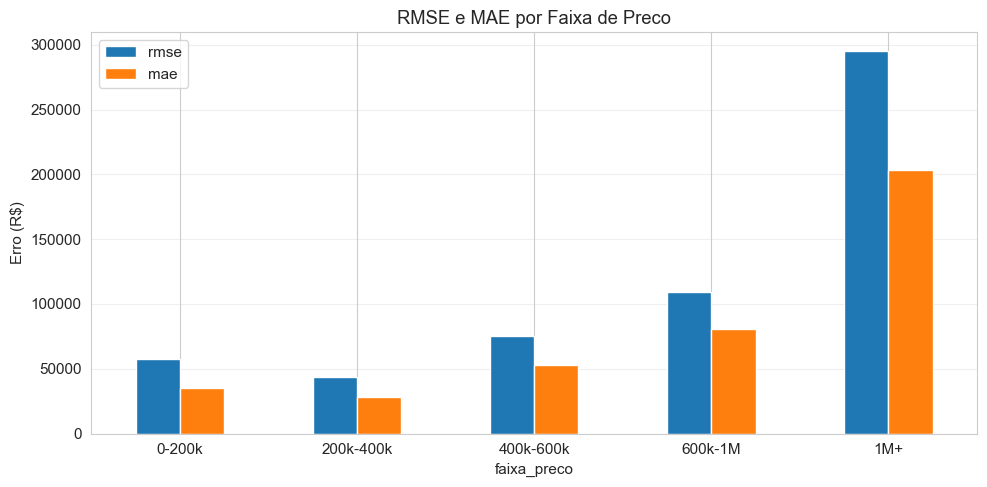

In [9]:
bins = [0, 200_000, 400_000, 600_000, 1_000_000, float("inf")]
labels = ["0-200k", "200k-400k", "400k-600k", "600k-1M", "1M+"]
test["faixa_preco"] = pd.cut(test["valor_imovel"], bins=bins, labels=labels, right=False)

def calc_rmse(grupo):
    return np.sqrt(mean_squared_error(grupo["valor_imovel"], grupo["valor_predito"]))

metricas_faixa = test.groupby("faixa_preco", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "rmse": calc_rmse(g),
        "mae": g["erro_abs"].mean(),
        "r2": r2_score(g["valor_imovel"], g["valor_predito"]) if len(g) > 1 else np.nan,
        "mdape": np.nanmedian(g["erro_percentual"]),
    })
).round(0)

print("Metricas por faixa de preco:")
print(metricas_faixa.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
metricas_faixa[["rmse", "mae"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Erro (R$)")
ax.set_title("RMSE e MAE por Faixa de Preco")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 8. Analise por Bairro

C:\Users\jefer\AppData\Local\Temp\ipykernel_14464\1036804207.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metricas_bairro = test.groupby("bairro").apply(


Bairros com >= 10 registros: 37

Top 10 bairros (menor RMSE):
                       n     rmse      mae  valor_medio  predicao_media  mdape
bairro                                                                        
jardim paraiso      20.0  35453.0  25355.0     404831.0        388575.0    4.0
ulysses guimaraes   11.0  38557.0  26786.0     416636.0        421779.0    4.0
morro do meio       12.0  58113.0  39438.0     452500.0        469935.0    5.0
adhemar garcia      39.0  64133.0  44522.0     405462.0        388158.0    8.0
joao costa          63.0  75322.0  45025.0     515862.0        507578.0    6.0
petropolis          53.0  78147.0  58433.0     498906.0        496364.0   10.0
espinheiros         28.0  78675.0  47375.0     555143.0        545967.0    5.0
jardim iririu       50.0  79648.0  48857.0     516442.0        520355.0    7.0
aventureiro        120.0  83629.0  47407.0     511630.0        497288.0    6.0
boehmerwald         56.0  84505.0  55887.0     468805.0        448831

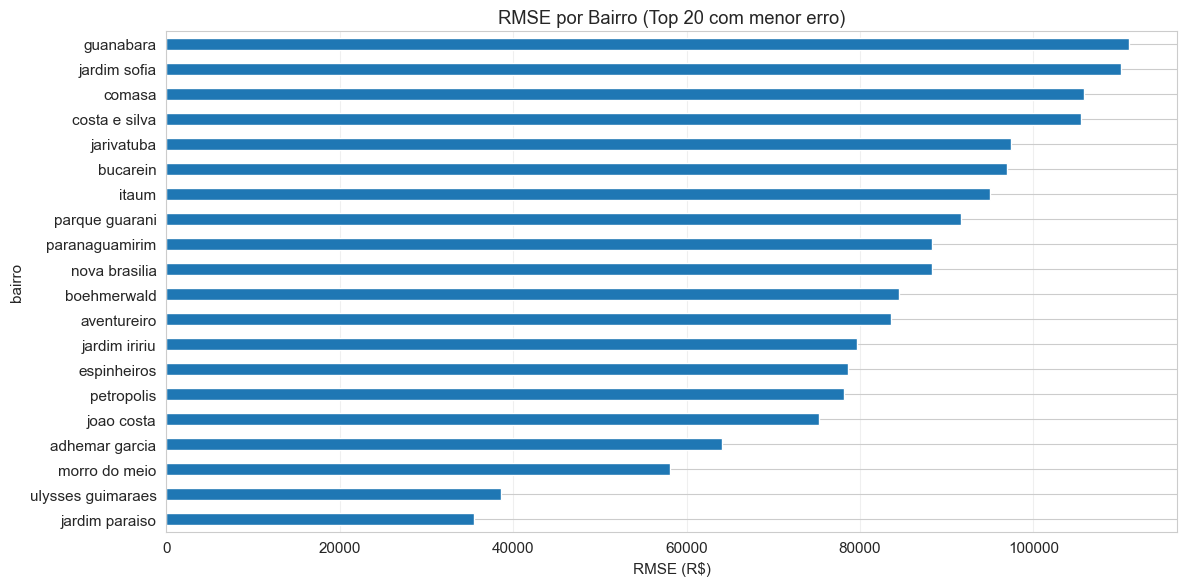

In [10]:
def calc_rmse(grupo):
    return np.sqrt(mean_squared_error(grupo["valor_imovel"], grupo["valor_predito"]))

metricas_bairro = test.groupby("bairro").apply(
    lambda g: pd.Series({
        "n": len(g),
        "rmse": calc_rmse(g),
        "mae": g["erro_abs"].mean(),
        "valor_medio": g["valor_imovel"].mean(),
        "predicao_media": g["valor_predito"].mean(),
        "mdape": np.nanmedian(g["erro_percentual"]),
    })
).round(0)

metricas_bairro = metricas_bairro[metricas_bairro["n"] >= 10]
metricas_bairro = metricas_bairro.sort_values("rmse")

print(f"Bairros com >= 10 registros: {len(metricas_bairro)}")
print(f"\nTop 10 bairros (menor RMSE):")
print(metricas_bairro.head(10).to_string())
print(f"\nTop 10 piores bairros (maior RMSE):")
print(metricas_bairro.tail(10).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
metricas_bairro.head(20).plot(kind="barh", y="rmse", ax=ax, legend=False)
ax.set_xlabel("RMSE (R$)")
ax.set_title("RMSE por Bairro (Top 20 com menor erro)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 9. Top 10 Piores Predicoes

Top 10 piores predicoes:

1. CASA...
   Bairro: gloria | Metragem: 455.7m2
   Real: R$ 3,100,000 | Predito: R$ 1,166,054 | Erro: R$ 1,933,946 (62.4%)

2. Casa de Condomínio com 3 Quartos à venda, 345m² - Saguaçu...
   Bairro: saguacu | Metragem: 345.0m2
   Real: R$ 5,100,000 | Predito: R$ 3,310,092 | Erro: R$ 1,789,908 (35.1%)

3. Apartamento com 3 Quartos à venda, 292m² - América...
   Bairro: america | Metragem: 292.0m2
   Real: R$ 5,995,000 | Predito: R$ 4,252,349 | Erro: R$ 1,742,651 (29.1%)

4. Casa para Venda em Joinville, Bom Retiro, 4 dormitórios, 1 s...
   Bairro: bom retiro | Metragem: 120.0m2
   Real: R$ 2,300,000 | Predito: R$ 814,875 | Erro: R$ 1,485,125 (64.6%)

5. Casa de alto padrão, AVERBADA com terreno de 1.380m² à venda...
   Bairro: gloria | Metragem: 234.0m2
   Real: R$ 3,200,000 | Predito: R$ 1,738,601 | Erro: R$ 1,461,399 (45.7%)

6. Casa de alvenaria à venda em Pirabeiraba - Joinville/SC...
   Bairro: pirabeiraba | Metragem: 125.0m2
   Real: R$ 3,170,000 | Predi

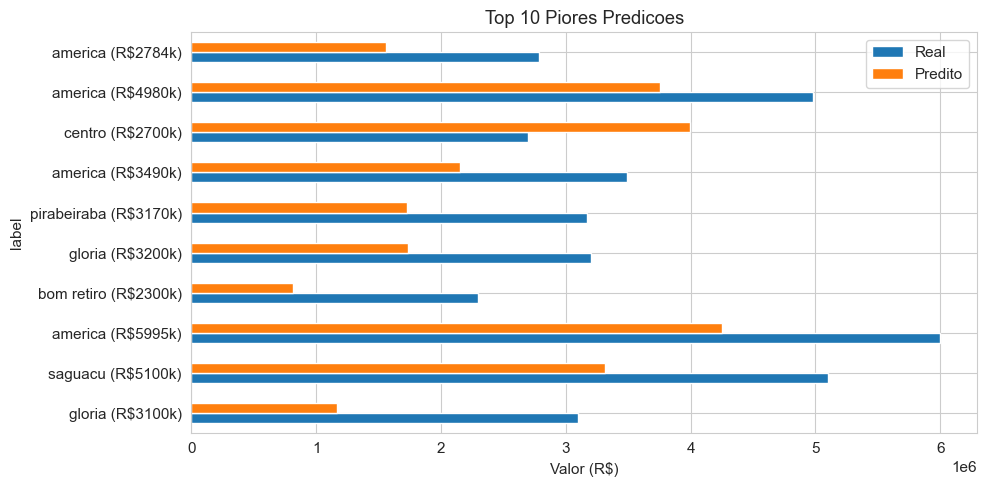

In [11]:
cols_saida = ["titulo", "bairro", "metragem", "quartos", "valor_imovel", "valor_predito", "erro_abs", "erro_percentual"]
cols_existentes = [c for c in cols_saida if c in test.columns]
piores = test.nlargest(10, "erro_abs")[cols_existentes]

print("Top 10 piores predicoes:")
for i, (idx, row) in enumerate(piores.iterrows(), 1):
    titulo = str(row.get("titulo", ""))[:60]
    bairro = row.get("bairro", "N/A")
    metragem = row.get("metragem", "N/A")
    real = row["valor_imovel"]
    predita = row["valor_predito"]
    erro = row["erro_abs"]
    erro_pct = row.get("erro_percentual", 0)
    print(f"\n{i}. {titulo}...")
    print(f"   Bairro: {bairro} | Metragem: {metragem}m2")
    print(f"   Real: R$ {real:,.0f} | Predito: R$ {predita:,.0f} | Erro: R$ {erro:,.0f} ({erro_pct:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
piores_graf = piores.copy()
piores_graf["label"] = piores_graf.apply(
    lambda r: f"{str(r.get('bairro', ''))[:15]} (R${r['valor_imovel']/1000:.0f}k)", axis=1
)
piores_graf.plot(kind="barh", x="label", y=["valor_imovel", "valor_predito"], ax=ax)
ax.set_xlabel("Valor (R$)")
ax.set_title("Top 10 Piores Predicoes")
ax.legend(["Real", "Predito"])
plt.tight_layout()
plt.show()

## 10. Feature Importance

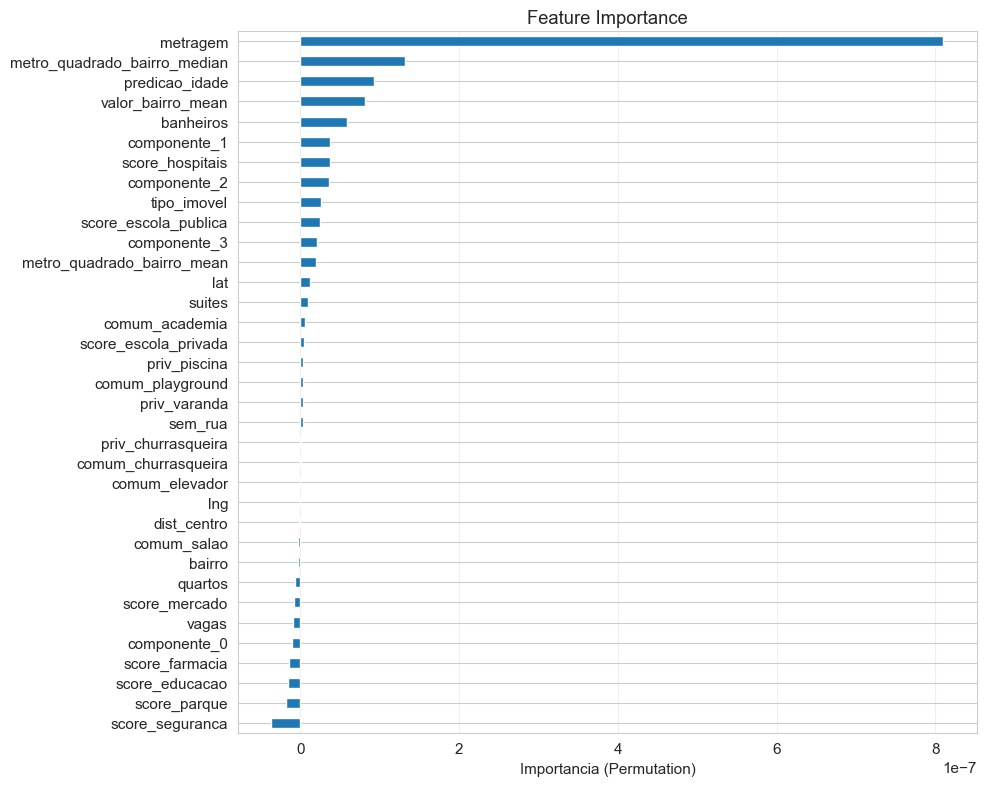

In [12]:
from sklearn.inspection import permutation_importance

X_test_filtered = test[[c for c in best_features if c in test.columns]]
result = permutation_importance(modelo, X_test_filtered, test["valor_imovel"], n_repeats=10, random_state=42)
importance = pd.Series(result.importances_mean, index=X_test_filtered.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind="barh", ax=ax)
ax.set_xlabel("Importancia (Permutation)")
ax.set_title("Feature Importance")
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 11. QQ Plot e Boxplot dos Residuos

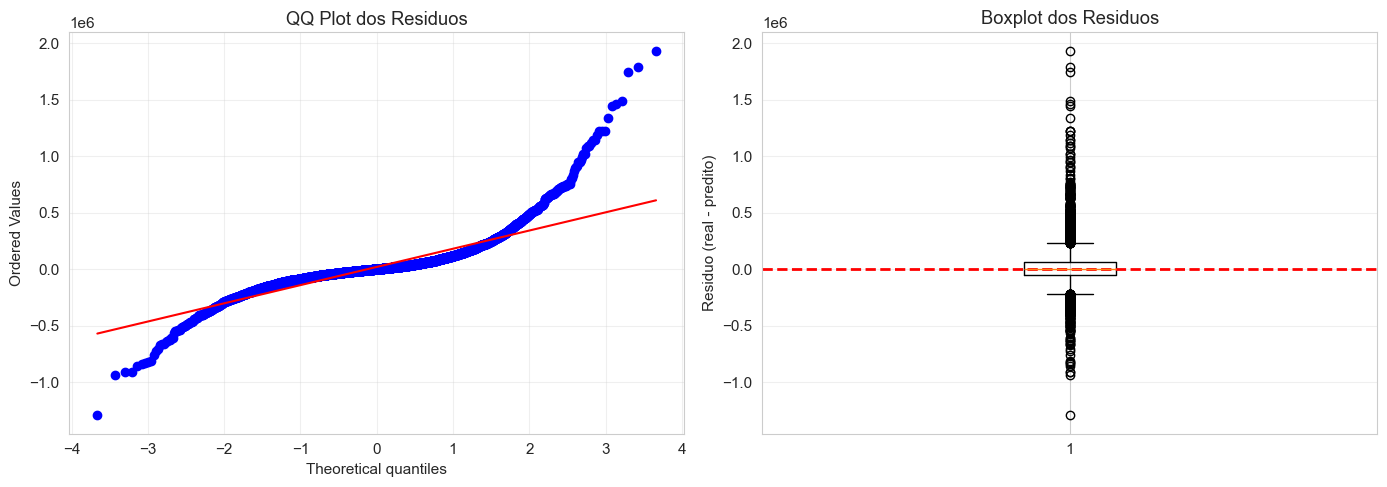

Estatisticas dos residuos:
  Media: R$ 20,818
  Mediana: R$ 1,737
  Desvio padrao: R$ 179,443
  Assimetria: 1.8751
  Curtose: 15.3551

Teste de Shapiro-Wilk:
  Estatistica: 0.7980
  p-value: 0.000000
  Normal: Nao (alpha=0.05)


In [13]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuos = test["erro"].dropna()
stats.probplot(residuos, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot dos Residuos")
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(residuos, vert=True)
axes[1].set_ylabel("Residuo (real - predito)")
axes[1].set_title("Boxplot dos Residuos")
axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("Estatisticas dos residuos:")
print(f"  Media: R$ {residuos.mean():,.0f}")
print(f"  Mediana: R$ {residuos.median():,.0f}")
print(f"  Desvio padrao: R$ {residuos.std():,.0f}")
print(f"  Assimetria: {residuos.skew():.4f}")
print(f"  Curtose: {residuos.kurtosis():.4f}")

stat, p_value = stats.shapiro(residuos.sample(min(5000, len(residuos)), random_state=42))
print(f"\nTeste de Shapiro-Wilk:")
print(f"  Estatistica: {stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Normal: {'Sim' if p_value > 0.05 else 'Nao'} (alpha=0.05)")

## 12. Resumo Final

In [14]:
print("=" * 60)
print("RESUMO DA AVALIACAO DO PREDITOR DE PRECO")
print("=" * 60)
print(f"\nModelo: {best['modelo']}")
print(f"Features: {len(best_features)}")
print(f"Target transform: {target_transform}")
print(f"\nMetricas no conjunto de teste ({len(test)} registros):")
print(f"  RMSE:   R$ {rmse:,.0f}")
print(f"  MAE:    R$ {mae:,.0f}")
print(f"  R2:     {r2:.3f}")
print(f"  MDAPE:  {mdape:.1f}%")
print(f"\nDistribuicao por faixa:")
print(test["faixa_preco"].value_counts().sort_index().to_string())
print(f"\n{'=' * 60}")

RESUMO DA AVALIACAO DO PREDITOR DE PRECO

Modelo: GradientBoosting
Features: 35
Target transform: log

Metricas no conjunto de teste (5527 registros):
  RMSE:   R$ 180,631
  MAE:    R$ 104,264
  R2:     0.941
  MDAPE:  8.0%

Distribuicao por faixa:
faixa_preco
0-200k         18
200k-400k    1048
400k-600k    1078
600k-1M      1623
1M+          1760



In [15]:
test[["valor_imovel", "valor_predito", "erro", "erro_percentual"]].head(50)

,valor_imovel,valor_predito,erro,erro_percentual
18734,580000.0,6.466808e+05,-66680.806386,11.496691
6971,450000.0,4.384742e+05,11525.751743,2.561278
17296,770000.0,6.771595e+05,92840.527616,12.057211
14933,3800000.0,3.402672e+06,397327.801636,10.455995
2308,1726560.0,2.047721e+06,-321161.070056,18.601211
7066,420000.0,3.879063e+05,32093.693490,7.641356
17973,320000.0,3.525970e+05,-32597.002329,10.186563
2585,1521000.0,1.474165e+06,46834.854823,3.079215
19845,3750000.0,4.285265e+06,-535264.744038,14.273727
5134,658899.0,6.426370e+05,16261.992043,2.468055


# Predizer precos para os dados limpos

In [16]:
df_limpo = pd.read_parquet(PASTA_DADOS / f"joinville_imoveis_limpo_{MES_REF}.parquet")
print(f"Parquet limpo: {len(df_limpo)} linhas, {len(df_limpo.columns)} colunas")

antes = len(df_limpo)
df_limpo = df_limpo[
    (df_limpo["valor_imovel"] > 0) &
    (df_limpo["valor_imovel"] <= 6_000_000)
]
print(f"Filtro outliers (<=6M): {antes} -> {len(df_limpo)} ({antes - len(df_limpo)} removidos)")

Parquet limpo: 24235 linhas, 83 colunas
Filtro outliers (<=6M): 24235 -> 23976 (259 removidos)


In [17]:
indices_full = None
try:
    indices_full = CriandoIndicesIndividuais(cidade="Joinville, Santa Catarina, Brasil", cache_dir=PASTA_DADOS)
    df_limpo = indices_full.calcular_indices(imoveis_df=df_limpo)
except Exception as e:
    print(f"Erro ao calcular indices: {e}")

df_limpo, _ = engenharia_features_completa(df_limpo, df_limpo.copy())

if any(c.startswith("componente_") for c in best_features):
    topicos_path = PASTA_DADOS / f"{CIDADE}_topicos_modelo.pkl"
    if topicos_path.exists():
        topicos_data = joblib.load(topicos_path)
        from utils_topicos import aplicar_topicos
        aplicar_topicos(df_limpo, topicos_data)
        print("Topicos aplicados ao dataset completo.")
    else:
        print("Modelo de topicos nao encontrado. Zerando colunas componente_*.")
        for c in best_features:
            if c.startswith("componente_"):
                df_limpo[c] = 0.0

for col in best_features:
    if col not in df_limpo.columns:
        if col in ["bairro_cluster", "novo_lancamento", "tem_elevador", "sem_rua"]:
            df_limpo[col] = 0

X_pred = df_limpo[[c for c in best_features if c in df_limpo.columns]]
y_pred_raw = modelo.predict(X_pred)

if target_transform == "log":
    df_limpo["valor_predito"] = np.expm1(y_pred_raw)
else:
    df_limpo["valor_predito"] = y_pred_raw

print(f"valor_predito adicionada ({len(df_limpo)} registros)")
print(f"Media: R$ {df_limpo['valor_predito'].mean():,.0f}")
print(f"Mediana: R$ {df_limpo['valor_predito'].median():,.0f}")
print(f"Min: R$ {df_limpo['valor_predito'].min():,.0f}")
print(f"Max: R$ {df_limpo['valor_predito'].max():,.0f}")

  Carregando POIs do cache: ..\dados\joinville\pois_joinville_santa_catarina_brasil.parquet
Topicos aplicados ao dataset completo.
valor_predito adicionada (23976 registros)
Media: R$ 978,049
Mediana: R$ 755,514
Min: R$ 7,199
Max: R$ 12,103,899


In [18]:
# df_limpo.to_parquet(PASTA_DADOS / f"joinville_imoveis_limpo_{MES_REF}.parquet")